In [2]:
import os

# Define paths
base_dir = 'Dataset'
train_dir = os.path.join(base_dir, 'train')
test_dir = os.path.join(base_dir, 'test')

# Print class folders inside train and test
print("Train categories:", os.listdir(train_dir))
print("Test categories:", os.listdir(test_dir))


Train categories: ['Medical', 'Bio-degradable', 'Non-degradable', 'Recyclable', 'Electronic']
Test categories: ['Medical', 'Bio-degradable', 'Non-degradable', 'Recyclable', 'Electronic']


In [3]:
import sys
print(sys.executable)


/home/abhishek/.pyenv/versions/3.10.13/bin/python


In [4]:
from tensorflow.keras.preprocessing.image import ImageDataGenerator

# Image size and batch size
IMG_SIZE = (224, 224)
BATCH_SIZE = 32

# Augmentation for training set
train_datagen = ImageDataGenerator(
    rescale=1./255,
    rotation_range=25,
    zoom_range=0.2,
    width_shift_range=0.1,
    height_shift_range=0.1,
    shear_range=0.1,
    horizontal_flip=True,
    fill_mode='nearest'
)

# Only rescaling for test set
test_datagen = ImageDataGenerator(rescale=1./255)

# Creating the data generators
train_generator = train_datagen.flow_from_directory(
    train_dir,
    target_size=IMG_SIZE,
    batch_size=BATCH_SIZE,
    class_mode='categorical'
)

test_generator = test_datagen.flow_from_directory(
    test_dir,
    target_size=IMG_SIZE,
    batch_size=BATCH_SIZE,
    class_mode='categorical'
)


2025-05-01 15:19:36.276204: I tensorflow/core/util/port.cc:153] oneDNN custom operations are on. You may see slightly different numerical results due to floating-point round-off errors from different computation orders. To turn them off, set the environment variable `TF_ENABLE_ONEDNN_OPTS=0`.
2025-05-01 15:19:36.286375: I external/local_xla/xla/tsl/cuda/cudart_stub.cc:32] Could not find cuda drivers on your machine, GPU will not be used.
2025-05-01 15:19:36.359627: I external/local_xla/xla/tsl/cuda/cudart_stub.cc:32] Could not find cuda drivers on your machine, GPU will not be used.
2025-05-01 15:19:36.414998: E external/local_xla/xla/stream_executor/cuda/cuda_fft.cc:467] Unable to register cuFFT factory: Attempting to register factory for plugin cuFFT when one has already been registered
E0000 00:00:1746092976.477585   45342 cuda_dnn.cc:8579] Unable to register cuDNN factory: Attempting to register factory for plugin cuDNN when one has already been registered
E0000 00:00:1746092976.49

Found 34277 images belonging to 5 classes.
Found 8673 images belonging to 5 classes.


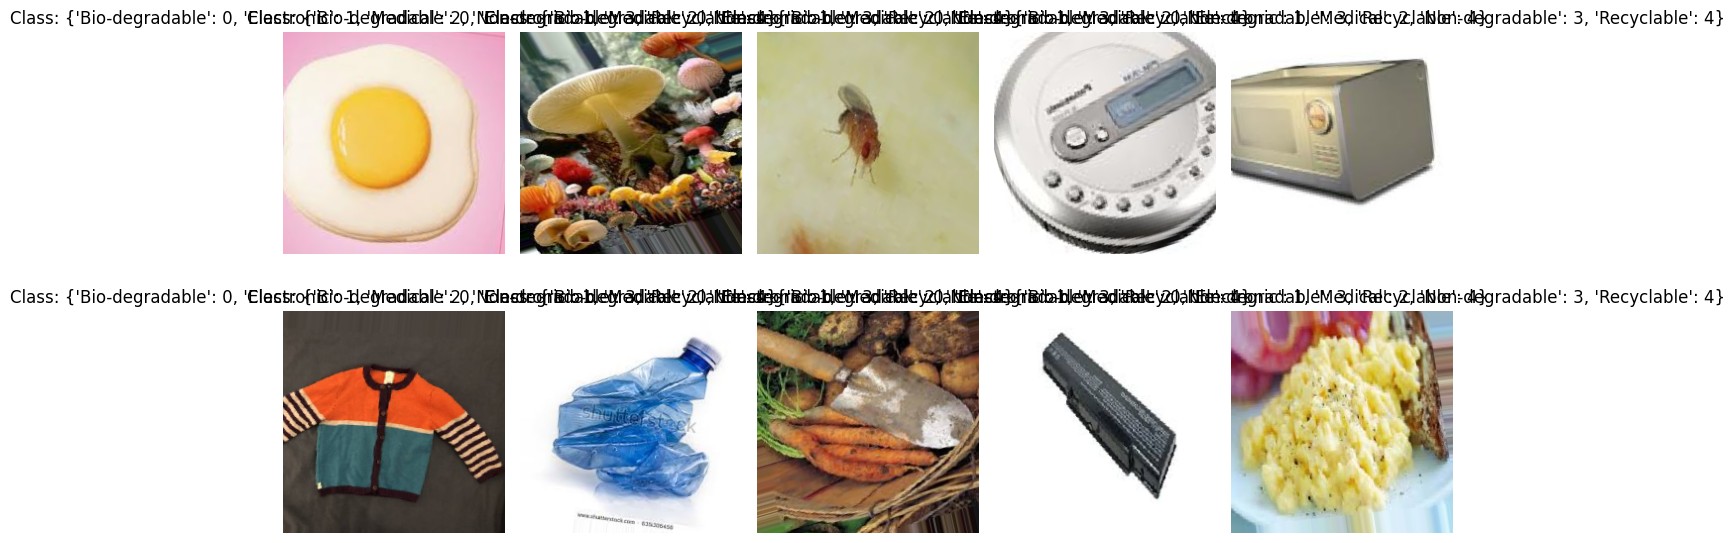

In [5]:
import matplotlib.pyplot as plt

# Get a batch of augmented images
images, labels = next(train_generator)

# Plot 10 augmented images
plt.figure(figsize=(12, 6))
for i in range(10):
    plt.subplot(2, 5, i + 1)
    plt.imshow(images[i])
    plt.axis('off')
    plt.title(f"Class: {train_generator.class_indices}")
plt.tight_layout()
plt.show()


In [6]:
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import Conv2D, MaxPooling2D, Flatten, Dense, Dropout, BatchNormalization

model = Sequential([
    # Convolutional Block 1
    Conv2D(32, (3, 3), activation='relu', input_shape=(224, 224, 3)),
    MaxPooling2D(pool_size=(2, 2)),
    BatchNormalization(),

    # Convolutional Block 2
    Conv2D(64, (3, 3), activation='relu'),
    MaxPooling2D(pool_size=(2, 2)),
    BatchNormalization(),

    # Convolutional Block 3
    Conv2D(128, (3, 3), activation='relu'),
    MaxPooling2D(pool_size=(2, 2)),
    BatchNormalization(),

    # Fully Connected Layers
    Flatten(),
    Dense(128, activation='relu'),
    Dropout(0.5),
    Dense(5, activation='softmax')  # 5 classes
])


/home/abhishek/.pyenv/versions/3.10.13/lib/python3.10/site-packages/keras/src/layers/convolutional/base_conv.py:107: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)
2025-05-01 15:19:57.723082: E external/local_xla/xla/stream_executor/cuda/cuda_platform.cc:51] failed call to cuInit: INTERNAL: CUDA error: Failed call to cuInit: UNKNOWN ERROR (303)


In [7]:
from tensorflow.keras import Input, Model
from tensorflow.keras.layers import Conv2D, MaxPooling2D, Flatten, Dense, Dropout, BatchNormalization

inputs = Input(shape=(224, 224, 3))

x = Conv2D(32, (3, 3), activation='relu')(inputs)
x = MaxPooling2D(pool_size=(2, 2))(x)
x = BatchNormalization()(x)

x = Conv2D(64, (3, 3), activation='relu')(x)
x = MaxPooling2D(pool_size=(2, 2))(x)
x = BatchNormalization()(x)

x = Conv2D(128, (3, 3), activation='relu')(x)
x = MaxPooling2D(pool_size=(2, 2))(x)
x = BatchNormalization()(x)

x = Flatten()(x)
x = Dense(128, activation='relu', name="feature_layer")(x)
x = Dropout(0.5)(x)
outputs = Dense(5, activation='softmax')(x)  # 5 classes

model = Model(inputs=inputs, outputs=outputs)


In [8]:
from tensorflow.keras.optimizers import Adam
from tensorflow.keras.callbacks import EarlyStopping

# Compile the model
model.compile(
    optimizer=Adam(learning_rate=0.001),
    loss='categorical_crossentropy',
    metrics=['accuracy']
)

# Early stopping to prevent overfitting
early_stop = EarlyStopping(monitor='val_loss', patience=5, restore_best_weights=True)

# Train the model
history = model.fit(
    train_generator,
    validation_data=test_generator,
    epochs=10,
    callbacks=[early_stop]
)


/home/abhishek/.pyenv/versions/3.10.13/lib/python3.10/site-packages/keras/src/trainers/data_adapters/py_dataset_adapter.py:121: UserWarning: Your `PyDataset` class should call `super().__init__(**kwargs)` in its constructor. `**kwargs` can include `workers`, `use_multiprocessing`, `max_queue_size`. Do not pass these arguments to `fit()`, as they will be ignored.
  self._warn_if_super_not_called()


Epoch 1/10
1072/1072 ━━━━━━━━━━━━━━━━━━━━ 2892s 3s/step - accuracy: 0.5027 - loss: 8.2911 - val_accuracy: 0.6355 - val_loss: 0.9194
Epoch 2/10
1072/1072 ━━━━━━━━━━━━━━━━━━━━ 1866s 2s/step - accuracy: 0.5859 - loss: 1.0357 - val_accuracy: 0.6558 - val_loss: 0.8799
Epoch 3/10
1072/1072 ━━━━━━━━━━━━━━━━━━━━ 2476s 2s/step - accuracy: 0.6048 - loss: 1.0011 - val_accuracy: 0.6585 - val_loss: 0.8305
Epoch 4/10
1072/1072 ━━━━━━━━━━━━━━━━━━━━ 12180s 11s/step - accuracy: 0.6136 - loss: 0.9841 - val_accuracy: 0.6811 - val_loss: 0.8426
Epoch 5/10
1072/1072 ━━━━━━━━━━━━━━━━━━━━ 2274s 2s/step - accuracy: 0.6195 - loss: 0.9804 - val_accuracy: 0.6498 - val_loss: 0.9253
Epoch 6/10
1072/1072 ━━━━━━━━━━━━━━━━━━━━ 3754s 4s/step - accuracy: 0.6271 - loss: 0.9549 - val_accuracy: 0.4543 - val_loss: 2.9198
Epoch 7/10
1072/1072 ━━━━━━━━━━━━━━━━━━━━ 1713s 2s/step - accuracy: 0.6423 - loss: 0.9302 - val_accuracy: 0.6428 - val_loss: 0.8999
Epoch 8/10
1072/1072 ━━━━━━━━━━━━━━━━━━━━ 1943s 2s/step - accuracy: 0.6451

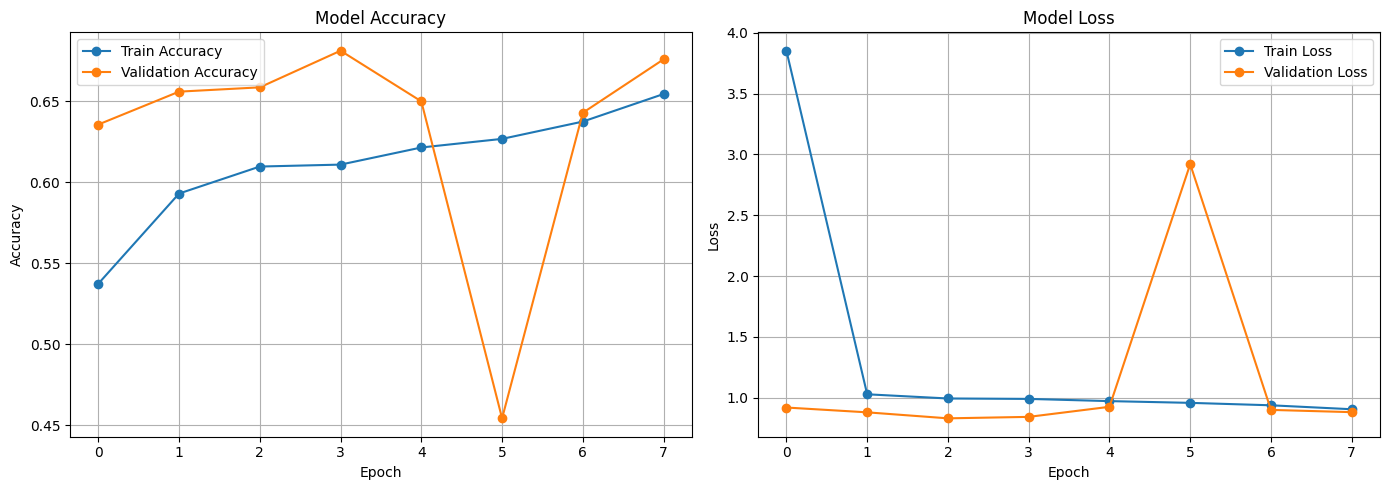

In [9]:
import matplotlib.pyplot as plt

# Plot training & validation accuracy values
plt.figure(figsize=(14, 5))

plt.subplot(1, 2, 1)
plt.plot(history.history['accuracy'], label='Train Accuracy', marker='o')
plt.plot(history.history['val_accuracy'], label='Validation Accuracy', marker='o')
plt.title('Model Accuracy')
plt.xlabel('Epoch')
plt.ylabel('Accuracy')
plt.legend()
plt.grid(True)

# Plot training & validation loss values
plt.subplot(1, 2, 2)
plt.plot(history.history['loss'], label='Train Loss', marker='o')
plt.plot(history.history['val_loss'], label='Validation Loss', marker='o')
plt.title('Model Loss')
plt.xlabel('Epoch')
plt.ylabel('Loss')
plt.legend()
plt.grid(True)

plt.tight_layout()
plt.show()


In [3]:
import numpy as np
from sklearn.metrics import classification_report, confusion_matrix
import seaborn as sns

# Predict on test data
y_pred_probs = model.predict(test_generator)
y_pred = np.argmax(y_pred_probs, axis=1)
y_true = test_generator.classes

# Class labels
class_labels = list(test_generator.class_indices.keys())

# Confusion Matrix
cm = confusion_matrix(y_true, y_pred)

plt.figure(figsize=(8, 6))
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues', xticklabels=class_labels, yticklabels=class_labels)
plt.xlabel('Predicted')
plt.ylabel('Actual')
plt.title('Confusion Matrix')
plt.show()

# Classification Report
print("Classification Report:\n")
print(classification_report(y_true, y_pred, target_names=class_labels))


NameError: name 'model' is not defined

In [11]:
from tensorflow.keras.preprocessing import image
import numpy as np

img = image.load_img('path/to/image.jpg', target_size=(224, 224))
img_array = image.img_to_array(img) / 255.0
img_array = np.expand_dims(img_array, axis=0)

prediction = model.predict(img_array)
predicted_class = class_labels[np.argmax(prediction)]
print("Predicted class:", predicted_class)


FileNotFoundError: [Errno 2] No such file or directory: 'path/to/image.jpg'